In [1]:
import requests
import matplotlib.pyplot as plt 
import pandas as pd 
import requests

#Token stored as environment variable for security
import os 

In [2]:
# URL for USGS Stehekin River Station for December 2025
url_1 = "https://waterservices.usgs.gov/nwis/dv/?format=json&sites=12451000&startDT=2025-12-01&endDT=2025-12-31&siteStatus=all"
url_2 = "https://waterservices.usgs.gov/nwis/dv/?format=json&sites=12451000&startDT=2024-12-01&endDT=2024-12-31&siteStatus=all"

# Url for debris flow event on December 15, 2025
r = requests.get(url_1)
data = r.json()
df_1 = pd.DataFrame(data["value"]["timeSeries"][0]["values"][0]["value"])
df_1["dateTime"] = pd.to_datetime(df_1["dateTime"])
df_1["value"] = pd.to_numeric(df_1["value"])

#Url for regular day (same day) on December 15, 2024
r = requests.get(url_2)
data = r.json()
df_2 = pd.DataFrame(data["value"]["timeSeries"][0]["values"][0]["value"])
df_2["dateTime"] = pd.to_datetime(df_2["dateTime"])
df_2["value"] = pd.to_numeric(df_2["value"])

print("/n Maximum Discharge Values:")
print(max(df_1["value"]))
print(max(df_2["value"]))

/n Maximum Discharge Values:
14300
495


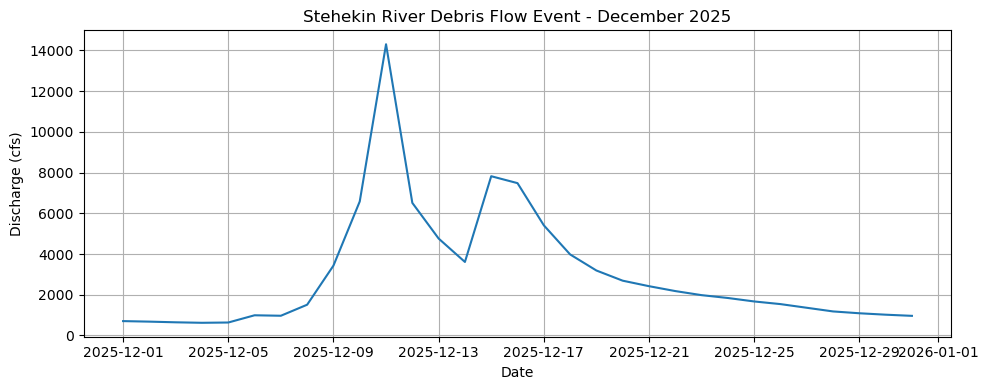

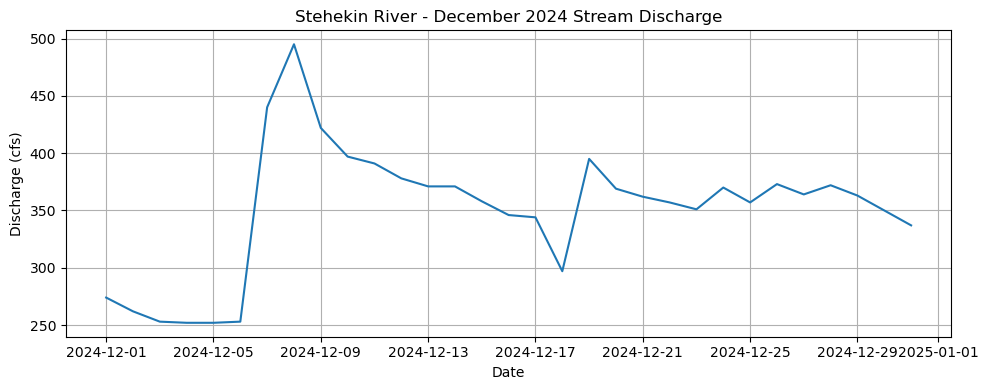

In [3]:
plt.figure(figsize=(10, 4))
plt.plot(df_1["dateTime"], df_1["value"])
plt.xlabel("Date")
plt.ylabel("Discharge (cfs)")
plt.title("Stehekin River Debris Flow Event - December 2025")
plt.grid(True)
plt.tight_layout()
plt.show()

#Plot historical (regular) day for streamflow 
plt.figure(figsize=(10, 4))
plt.plot(df_2['dateTime'], df_2['value'])
plt.xlabel("Date")
plt.ylabel("Discharge (cfs)")
plt.title("Stehekin River - December 2024 Stream Discharge")
plt.grid(True)
plt.tight_layout()
plt.show()

<Response [200]>
{'metadata': {'resultset': {'offset': 1, 'count': 31, 'limit': 25}}, 'results': [{'date': '2025-12-01T00:00:00', 'datatype': 'PRCP', 'station': 'GHCND:USC00458059', 'attributes': ',,7,0800', 'value': 0.0}, {'date': '2025-12-02T00:00:00', 'datatype': 'PRCP', 'station': 'GHCND:USC00458059', 'attributes': ',,7,0800', 'value': 4.1}, {'date': '2025-12-03T00:00:00', 'datatype': 'PRCP', 'station': 'GHCND:USC00458059', 'attributes': ',,7,0800', 'value': 0.0}, {'date': '2025-12-04T00:00:00', 'datatype': 'PRCP', 'station': 'GHCND:USC00458059', 'attributes': ',,7,0800', 'value': 1.5}, {'date': '2025-12-05T00:00:00', 'datatype': 'PRCP', 'station': 'GHCND:USC00458059', 'attributes': ',,7,0800', 'value': 5.1}, {'date': '2025-12-06T00:00:00', 'datatype': 'PRCP', 'station': 'GHCND:USC00458059', 'attributes': ',,7,0800', 'value': 34.8}, {'date': '2025-12-07T00:00:00', 'datatype': 'PRCP', 'station': 'GHCND:USC00458059', 'attributes': ',,7,0800', 'value': 18.3}, {'date': '2025-12-08T00:0

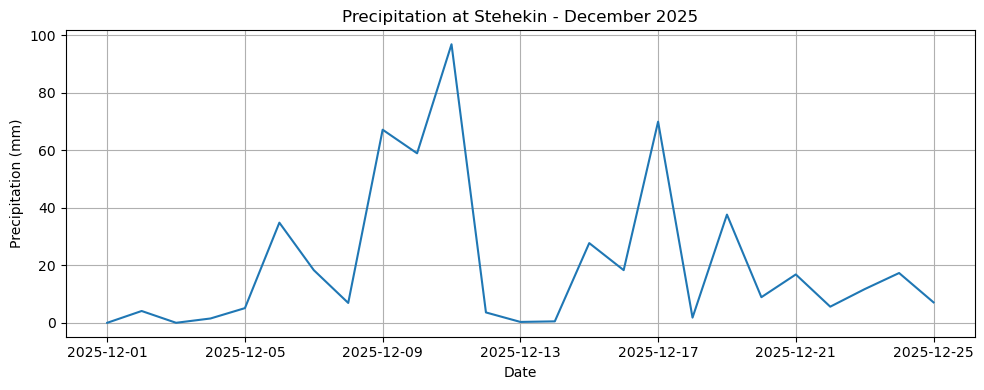

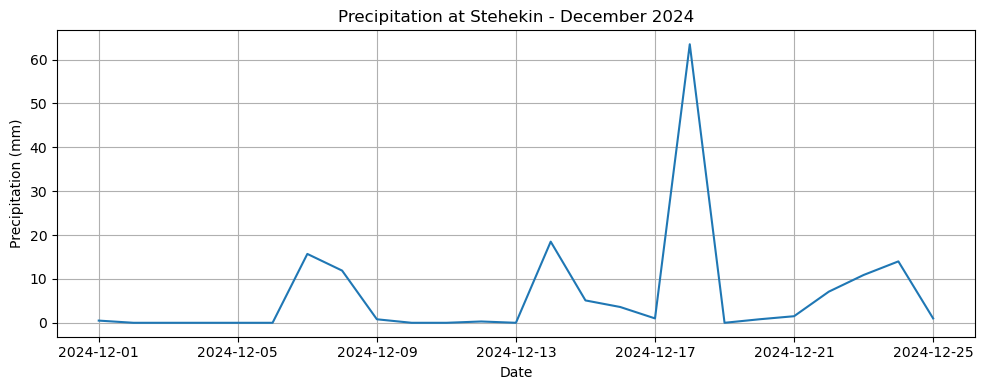

/n Maximum Precipitation Values:
96.8
63.5


In [ ]:
#Grab the NOAA Precip data for the December 2025 Event (daily data)
url_precip = "https://www.ncdc.noaa.gov/cdo-web/api/v2/data?datasetid=GHCND&datatypeid=PRCP&startdate=2025-12-01&enddate=2025-12-31&stationid=GHCND:USC00458059&units=metric"
headers = {
    'token': 'UViCnnqLTRyGmPrYttbtodvxAEBKZebQ'
}

response = requests.get(url_precip, headers=headers)
print(response)
data_precip = response.json()
print(data_precip)

df_precip = pd.DataFrame(data_precip['results'])
print(df_precip.head())

df_precip['date'] = pd.to_datetime(df_precip['date'])
df_precip['value'] = pd.to_numeric(df_precip['value'], errors='coerce') 

plt.figure(figsize=(10, 4))
plt.plot(df_precip['date'], df_precip['value'])
plt.xlabel("Date")
plt.ylabel("Precipitation (mm)")
plt.title("Precipitation at Stehekin - December 2025")
plt.grid(True)
plt.tight_layout()
plt.show()

#Grab data for december of previous year to get an idea of preciptation patterns 
url_precip_2 = "https://www.ncdc.noaa.gov/cdo-web/api/v2/data?datasetid=GHCND&datatypeid=PRCP&startdate=2024-12-01&enddate=2024-12-31&stationid=GHCND:USC00458059&units=metric"

response_2 = requests.get(url_precip_2, headers=headers)
data_precip_2 = response_2.json()

df_precip_2 = pd.DataFrame(data_precip_2['results'])
df_precip_2['date'] = pd.to_datetime(df_precip_2['date'])
df_precip_2['value'] = pd.to_numeric(df_precip_2['value'], errors='coerce')

plt.figure(figsize=(10, 4))
plt.plot(df_precip_2['date'], df_precip_2['value'])
plt.xlabel("Date")
plt.ylabel("Precipitation (mm)")
plt.title("Precipitation at Stehekin - December 2024")
plt.grid(True)
plt.tight_layout()
plt.show()

print("/n Maximum Precipitation Values:")
print(max(df_precip["value"]))
print(max(df_precip_2["value"]))

print("/n Total Monthly Precipitation:")
print(sum(df_precip["value"]))
print(sum(df_precip_2["value"]))